# Sequential Recommendation: What You're In the Mood For

Notebooks 1-4 built matrix factorization and neural collaborative filtering. Both treat a user's history as an unordered bag. An item consumed three months ago carries the same weight as one consumed yesterday.

This notebook drops that assumption. We apply the transformer from Course 1 directly to item sequences. The architecture is identical: same embeddings, same positional encoding, same causal attention. The only change is the vocabulary. Instead of characters, the tokens are item IDs.

That is the payoff. A transformer is not a language model. It is a sequence model. Swap the vocabulary and the application changes entirely.

| Notebook | What it models | Evaluation |
|----------|---------------|------------|
| 1: Matrix Factorization | User x item affinity | RMSE |
| 2: User/Item Biases | Affinity + systematic shifts | RMSE |
| 3: Neural CF | Nonlinear affinity | RMSE |
| 4: Content Features | Side information | RMSE |
| **5: Sequential (this)** | **Order of interactions** | **Hit@K** |

In [1]:
import random, math, matplotlib.pyplot as plt
%matplotlib inline

N_ITEMS = 120
N_GENRES = 6
ITEMS_PER_GENRE = N_ITEMS // N_GENRES  # 20 items per genre

def genre_of(item_id):
    """Which genre cluster does this item belong to?"""
    return item_id // ITEMS_PER_GENRE

def make_sequential_sequences(n_users=80, n_phases=4, items_per_phase=5, seed=42):
    """
    Build synthetic item sequences with genuine sequential structure.

    Each user goes through n_phases. In each phase they consume items_per_phase
    items from one genre. Genre order differs per user.

    A sequential model can learn: if the last few items are genre 2, the next
    item is probably also genre 2. A bag model cannot - it only sees which genres
    appear, not when.
    """
    rng = random.Random(seed)
    sequences = {}
    for u in range(n_users):
        seq = []
        # Each user gets n_phases genre phases in a random order
        phase_genres = [rng.randint(0, N_GENRES - 1) for _ in range(n_phases)]
        for genre in phase_genres:
            genre_items = list(range(genre * ITEMS_PER_GENRE, (genre + 1) * ITEMS_PER_GENRE))
            chosen = rng.sample(genre_items, items_per_phase)
            seq.extend(chosen)
        sequences[u] = seq
    return sequences

N_USERS = 80
sequences = make_sequential_sequences()
total = sum(len(s) for s in sequences.values())
print(f'{N_USERS} users, {N_ITEMS} items, {N_GENRES} genres of {ITEMS_PER_GENRE} items each')
print(f'Total interactions: {total}, avg sequence length: {total / N_USERS:.1f}')

80 users, 120 items, 6 genres of 20 items each
Total interactions: 1600, avg sequence length: 20.0


## Step 1: Why Order Matters

Matrix factorization assigns each user a fixed preference vector. Rate 3 action films and 3 romantic comedies, and your vector ends up somewhere between the two genres. The model averages your history and loses track of *when* you watched each one.

Here is the concrete problem. Suppose user A consumed items in this order:

```
t=1  Action
t=2  Action
t=3  Action
t=4  Romcom
t=5  Romcom
t=6  Romcom   <- most recent
```

A bag model sees: 3 action + 3 romcom. It recommends something in the middle. A sequential model sees: this user shifted from action to romcom. It recommends another romcom.

The signal is in the *transition*, not the aggregate. This matters whenever users have moods, phases, or evolving tastes.

### Generating sequences

To build data with genuine sequential structure, we group items into **genres**: 6 clusters of 20 items each, numbered by ID range (items 0-19 are genre 0, items 20-39 are genre 1, and so on).

Each user goes through **phases**: they consume `items_per_phase` items from one genre, then switch to another. The genre order differs per user. User A might go sci-fi, comedy, sci-fi, drama. User B might go drama, sci-fi, comedy, sci-fi.

The sequential model can exploit this: if the last few items in a context are all genre 2, the next item is probably also genre 2. A bag model cannot see this pattern. It only knows which genres the user has visited, not in what order.

In [2]:
# Show an example user's sequence with genre labels
example_user = 0
seq = sequences[example_user]
genres = [genre_of(item) for item in seq]

print(f'User {example_user}: {len(seq)} items across {N_GENRES} possible genres')
print(f'  Items:  {seq}')
print(f'  Genres: {genres}')
print()
print('Genre phases are visible: blocks of the same genre appear in sequence.')
print(f'\nSequence lengths: min={min(len(s) for s in sequences.values())}, '
      f'max={max(len(s) for s in sequences.values())}, '
      f'mean={sum(len(s) for s in sequences.values())/len(sequences):.1f}')

User 0: 20 items across 6 possible genres
  Items:  [108, 107, 118, 104, 103, 17, 2, 13, 1, 0, 2, 6, 7, 16, 0, 117, 106, 119, 113, 107]
  Genres: [5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 5, 5, 5, 5]

Genre phases are visible: blocks of the same genre appear in sequence.

Sequence lengths: min=20, max=20, mean=20.0


## Step 2: The Task: Next Item Prediction

We reframe recommendation as **next item prediction**: given a user's sequence of past items `[i₁, i₂, ..., iₙ₋₁]`, predict `iₙ`.

This is the language model task from Course 1, notebook 3. There, the sequence was characters and the next token was a character. Here, the sequence is item IDs and the next token is an item ID. The framing is identical.

### Building the dataset

From each user's sequence `[i₁, i₂, i₃, i₄]` we extract overlapping examples:

| Context (input) | Target |
|-----------------|--------|
| `[i₁]` | `i₂` |
| `[i₁, i₂]` | `i₃` |
| `[i₁, i₂, i₃]` | `i₄` |

We cap the context at `MAX_LEN=10`. Shorter contexts are **left-padded** with a special `PAD_ID`. Padding goes on the left so the most recent items are always at the rightmost positions.

### Why cross-entropy, not MSE

Previous notebooks minimised RMSE on star ratings: a regression problem. Here we are classifying which of the `N_ITEMS` items comes next. The output is a probability distribution over all items. **Cross-entropy loss** measures how much probability the model assigned to the correct item. A perfect prediction assigns probability 1 to the true next item, giving loss 0. A model that assigns equal probability to all items gives loss `log(N_ITEMS) ≈ 4.8` for 120 items.

We no longer predict star ratings at all. Whether the user would rate the next item 4 or 5 stars is irrelevant. We only care about *which* item it is.

In [3]:
MAX_LEN = 10
PAD_ID = N_ITEMS  # one extra ID beyond [0, N_ITEMS-1]

def make_examples(sequences, max_len=MAX_LEN):
    """For each user, make (context, target) pairs from their item sequence."""
    examples = []
    for user, item_seq in sequences.items():
        for t in range(1, len(item_seq)):
            context = item_seq[max(0, t - max_len):t]
            # Left-pad so most recent item is always at position -1
            context = [PAD_ID] * (max_len - len(context)) + context
            examples.append((context, item_seq[t]))
    return examples

all_examples = make_examples(sequences)

# Split by shuffling (not by user) so train/val see the same users
random.seed(42)
random.shuffle(all_examples)
split = int(0.8 * len(all_examples))
train_ex = all_examples[:split]
val_ex   = all_examples[split:]

# Inspect one example
ctx, tgt = train_ex[0]
print(f'Total examples: {len(all_examples)} (train={len(train_ex)}, val={len(val_ex)})')
print(f'Context (PAD_ID={PAD_ID}): {ctx}')
print(f'Target item: {tgt}')
print(f'\nBaseline cross-entropy (uniform): {math.log(N_ITEMS):.3f}')

Total examples: 1520 (train=1216, val=304)
Context (PAD_ID=120): [120, 120, 120, 120, 120, 120, 50, 42, 59, 43]
Target item: 52

Baseline cross-entropy (uniform): 4.787


## Step 3: The Transformer for Sequences

The architecture is the causal transformer from Course 1, notebook 3. Three components:

**Item embedding.** Each item ID maps to a learned vector of size `emb_dim`. The padding token gets its own embedding but its gradient is zeroed during training (PyTorch's `padding_idx` handles this). Size: `(N_ITEMS + 1) × emb_dim`.

**Positional embedding.** The transformer has no built-in sense of order. Without it, position 0 and position 9 look identical. We learn a separate vector for each of the `MAX_LEN` positions and add it to the item embedding. Size: `MAX_LEN × emb_dim`.

**Causal self-attention.** The attention mask prevents position `t` from attending to positions `t+1, t+2, ...`. This is the same mask from notebook 3: the model predicts the next item from the items seen so far, never peeking ahead. Without it, the model would see the answer during training.

The output of the transformer at the **last position** is fed through a linear layer that produces one logit per item. The item with the highest logit is the prediction.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Use GPU if available, otherwise CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


In [5]:
class SeqRec(nn.Module):
    def __init__(self, n_items, emb_dim=32, n_heads=2, n_layers=2, max_len=MAX_LEN):
        super().__init__()
        # +1 for the padding token; padding_idx zeros its gradient
        self.item_emb = nn.Embedding(n_items + 1, emb_dim, padding_idx=n_items)
        self.pos_emb  = nn.Embedding(max_len, emb_dim)
        layer = nn.TransformerEncoderLayer(
            emb_dim, n_heads, dim_feedforward=64,
            batch_first=True, norm_first=True, dropout=0.0
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.out = nn.Linear(emb_dim, n_items)
        # Near-zero output init so untrained logits are nearly uniform.
        # This makes the sanity check meaningful: loss should start near log(N_ITEMS).
        nn.init.normal_(self.out.weight, 0, 0.01)
        nn.init.zeros_(self.out.bias)
        self.max_len = max_len

    def forward(self, x):
        # x: (B, T) item IDs
        B, T = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0)  # (1, T)
        emb = self.item_emb(x) + self.pos_emb(positions)            # (B, T, emb_dim)
        # Causal mask: position t cannot attend to t+1, t+2, ...
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=x.device)
        out = self.transformer(emb, mask=mask, is_causal=True)      # (B, T, emb_dim)
        return self.out(out[:, -1, :])                               # (B, n_items)


torch.manual_seed(42)
model = SeqRec(N_ITEMS).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'SeqRec: {n_params:,} parameters')

# Sanity check: untrained model produces near-uniform logits.
# Expected cross-entropy = log(N_ITEMS).
dummy = torch.zeros(4, MAX_LEN, dtype=torch.long).to(device)
with torch.no_grad():
    logits = model(dummy)              # (4, N_ITEMS)
    loss = F.cross_entropy(logits, torch.zeros(4, dtype=torch.long).to(device))
print(f'Untrained loss: {loss.item():.3f}  (expected ~{math.log(N_ITEMS):.3f})')

SeqRec: 25,240 parameters
Untrained loss: 4.864  (expected ~4.787)


/var/folders/fm/09yk1c9d7g72f927444fzkyc0000gn/T/ipykernel_46632/2265720748.py:11: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)


## Step 4: Training and Evaluation

### Training

The loop is the standard four steps from notebook 1: predict, score (cross-entropy), assign blame (`.backward()`), nudge (Adam). We batch examples into groups of 64 and train for 20 epochs.

### Evaluation: Hit@K

RMSE measured how close a predicted rating was to the true rating. Here we have no star rating. We just need to recommend the right item.

**Hit@K** asks: was the true next item in the model's top-K recommendations? A Hit@10 of 0.25 means the correct item appears in the top 10 predictions 25% of the time. With 120 items, a random baseline gives Hit@10 = 10/120 ≈ 0.083.

We evaluate two K values:
- **Hit@10**: a tight constraint, useful when you show the user a short list
- **Hit@50**: a looser constraint, useful for filtering a large catalogue

In [6]:
def to_tensors(examples, device):
    contexts = torch.tensor([ctx for ctx, tgt in examples], dtype=torch.long)
    targets  = torch.tensor([tgt for ctx, tgt in examples], dtype=torch.long)
    return contexts.to(device), targets.to(device)

X_train, y_train = to_tensors(train_ex, device)
X_val,   y_val   = to_tensors(val_ex,   device)
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape},   y_val:   {y_val.shape}')

X_train: torch.Size([1216, 10]), y_train: torch.Size([1216])
X_val:   torch.Size([304, 10]),   y_val:   torch.Size([304])


/var/folders/fm/09yk1c9d7g72f927444fzkyc0000gn/T/ipykernel_46632/2265720748.py:11: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)


Epoch   5  loss=4.3498


Epoch  10  loss=3.5733


Epoch  15  loss=3.0784


Epoch  20  loss=2.6661


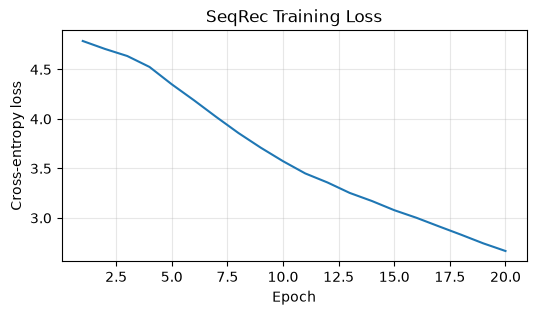

In [7]:
def train_seqrec(model, X_train, y_train, epochs=20, batch_size=64, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    n = X_train.shape[0]
    for epoch in range(epochs):
        model.train()
        # Shuffle training data each epoch
        perm = torch.randperm(n, device=X_train.device)
        epoch_loss = 0.0
        n_batches = 0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X_train[idx], y_train[idx]
            logits = model(xb)                    # (B, N_ITEMS)
            loss = F.cross_entropy(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d}  loss={avg_loss:.4f}')
    return losses

torch.manual_seed(42)
model = SeqRec(N_ITEMS).to(device)
losses = train_seqrec(model, X_train, y_train)

plt.figure(figsize=(6, 3))
plt.plot(range(1, len(losses)+1), losses)
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss')
plt.title('SeqRec Training Loss')
plt.grid(alpha=0.3)
plt.show()

In [8]:
def hit_at_k(model, X_val, y_val, k_values=(10, 50)):
    model.eval()
    with torch.no_grad():
        logits = model(X_val)  # (N_val, N_ITEMS)
    # Rank items by score (highest first)
    _, top_indices = logits.topk(max(k_values), dim=1)  # (N_val, max_k)
    hits = {}
    for k in k_values:
        top_k = top_indices[:, :k]                        # (N_val, k)
        # Check whether the true item appears in the top-k
        correct = (top_k == y_val.unsqueeze(1)).any(dim=1)  # (N_val,)
        hits[k] = correct.float().mean().item()
    return hits

hits = hit_at_k(model, X_val, y_val)
random_hit10 = 10 / N_ITEMS
random_hit50 = 50 / N_ITEMS
print('Evaluation on validation set:')
print(f'  Hit@10:  {hits[10]:.3f}  (random baseline: {random_hit10:.3f})')
print(f'  Hit@50:  {hits[50]:.3f}  (random baseline: {random_hit50:.3f})')

Evaluation on validation set:
  Hit@10:  0.345  (random baseline: 0.083)
  Hit@50:  0.845  (random baseline: 0.417)


## Step 5: The Connection to Course 1

The transformer in this notebook and the transformer in Course 1, notebook 3 are the same architecture. Here is the mapping:

| Course 1 (GPT) | Course 2 (SeqRec) |
|---------------|-------------------|
| Vocabulary: 65 characters | Vocabulary: 120 items |
| Token: one character | Token: one item ID |
| Context: sequence of chars | Context: sequence of rated items |
| Target: next character | Target: next item |
| Loss: cross-entropy over chars | Loss: cross-entropy over items |
| Embedding table: 65 × C | Embedding table: 121 × emb_dim |
| Positional embedding: T × C | Positional embedding: MAX_LEN × emb_dim |
| Causal mask | Causal mask |

The architecture is unchanged. The application changes because the vocabulary changes.

This generalises further. The same architecture predicts DNA sequences (vocabulary: 4 nucleotides), source code tokens (vocabulary: programming language tokens), musical notes, chess moves, or molecular structures. The transformer does not know or care what the tokens represent. It learns patterns in sequences.

In [9]:
# The SeqRec model and a GPT model are identical except for vocab size.
# Show the embedding shapes side by side.
gpt_vocab    = 65    # characters in tiny Shakespeare
seqrec_vocab = N_ITEMS + 1  # items + padding token

print('Embedding table sizes:')
print(f'  GPT (chars):    {gpt_vocab} x C')
print(f'  SeqRec (items): {seqrec_vocab} x emb_dim')
print()
print('Everything else is the same:')
print('  - Positional embedding: T x emb_dim')
print('  - Causal self-attention with the same upper-triangular mask')
print('  - Feed-forward sublayer')
print('  - Linear output head: emb_dim -> vocab_size')
print()
print('The output head projects to vocab_size logits.')
print('argmax of those logits is the model\'s top-1 prediction.')
print('Hit@K is just asking whether the true answer is in the top-K logits.')

Embedding table sizes:
  GPT (chars):    65 x C
  SeqRec (items): 121 x emb_dim

Everything else is the same:
  - Positional embedding: T x emb_dim
  - Causal self-attention with the same upper-triangular mask
  - Feed-forward sublayer
  - Linear output head: emb_dim -> vocab_size

The output head projects to vocab_size logits.
argmax of those logits is the model's top-1 prediction.
Hit@K is just asking whether the true answer is in the top-K logits.


## Summary

| Model | What it models | Input | Output | Metric |
|-------|---------------|-------|--------|--------|
| Matrix Factorization | Global user-item affinity | User ID, item ID | Rating | RMSE |
| Neural CF | Nonlinear affinity | User ID, item ID | Rating | RMSE |
| SeqRec (this) | Sequential patterns | Item ID sequence | Next item | Hit@K |

### What we learned

- **Bag models ignore order.** A user who shifted from action to romcom looks identical to one who mixed genres randomly. The sequential signal is lost.
- **Next item prediction is the language model task.** Swap characters for item IDs and the architecture is unchanged.
- **Cross-entropy, not MSE.** We are classifying which item comes next, not regressing a star rating.
- **Hit@K is the natural metric.** Was the correct item in the top K? Random baseline is K / N_ITEMS.
- **A transformer is a sequence model.** The vocabulary is a detail. Positional encoding, causal attention, and feed-forward layers are domain-agnostic.

## Your turn

### 1. Remove positional embeddings

In `SeqRec.__init__`, delete the `pos_emb` embedding. In `forward`, remove the `+ self.pos_emb(positions)` term. Retrain and evaluate Hit@10.

Without positional information, the model still sees which items are in the context but not their order. Does it perform better or worse than the full model? What does the result tell you about how much the *order* of items matters in this dataset?

### 2. Bidirectional attention (BERT4Rec style)

Remove the causal mask: delete the `mask=mask, is_causal=True` arguments from the `self.transformer(...)` call. Instead of predicting the *last* item from all previous items, randomly mask one item in the context and predict it from both its left and right neighbours.

To do this: before training, replace a random position in each context with `PAD_ID`. Record which position was masked. Use the transformer output at that position (not the last position) to predict the masked item. This is the BERT4Rec approach. Does Hit@K improve?

### 3. One head vs four heads

Train two models: one with `n_heads=1`, one with `n_heads=4` (keep `emb_dim=32`). Compare their Hit@10 after 20 epochs.

Multi-head attention lets the model attend to different positions for different reasons simultaneously. One head might track genre transitions; another might track recency. With a small vocabulary (120 items) and a small dataset, does the extra capacity help or hurt? Why might more heads sometimes hurt on small datasets?

> ➡ **Next:** [Exploration vs Exploitation](../recommendation_engine/6_exploration_exploitation.ipynb)